In [35]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
from math import sin, cos, sqrt, gcd, pi
import pandas as pd

In [36]:
def get_color_list(n, step, floor, start=0):
    ang = 2 * pi * step/n
    R = sqrt(1/3)
    k = 1 - floor
    coords = [[sqrt(6) / 3, R * cos(i * ang), R * sin(i * ang)] for i in range(n)]
    M = [[sqrt(3)/3, -sqrt(3)/3, -sqrt(3)/3],
         [sqrt(3)/3, (3+sqrt(3))/6, -(3-sqrt(3))/6],
         [sqrt(3)/3,  -(3-sqrt(3))/6, (3+sqrt(3))/6]]
    colors = []
    for xyz in coords:
        new = [floor + k * sum(a*b for a, b in zip(xyz, row)) for row in M]
        colors.append(new)
        # floor += (1 - floor) / n
        # k = 1 - floor
        x, y, z = xyz        
    return colors

In [37]:

tourney_df = pd.read_pickle('pickle/tourney_w_brackets_df.p')
tourney_df = tourney_df[
    (tourney_df['Iowa'] > 2) 
    & (tourney_df['Purdue'] > 2)
    & (tourney_df['Arizona'] > 3)
    & (tourney_df['Illinois'] > 3)
    & (tourney_df['Duke'] > 2)
    & (tourney_df['Michigan'] > 2)
    & (tourney_df['Connecticut'] > 2)
    & (tourney_df['Tennessee'] > 2)
    ]

tourney_df['Probability'] = tourney_df['Probability']/tourney_df['Probability'].sum()

current_df = tourney_df[['Winner', 'Probability']].groupby('Winner').sum().sort_values('Probability', ascending = False)
current_df['Probability'] = current_df['Probability']/current_df['Probability'].sum()

prize_cols = ['Winner', 'Second', 'Third']
titles = {'Winner' : '1st Place', 
          'Second' : '2nd Place', 
          'Third' : '3rd Place'}
disp_titles = []
all_labels = []
dfs = [current_df]

game1 = ["Tennessee", "Michigan"]
game2 = ["Connecticut", "Duke"]


In [38]:
all_labels = list(current_df.index)
all_colors = get_color_list(len(all_labels), 1, 0.5, start=0)
color_dict = {label: color for label, color in zip(all_labels, all_colors)}




In [39]:
def get_color_list(n, step, floor, start=0):
    ang = 2 * pi * step/n
    R = sqrt(1/3)
    k = 1 - floor
    coords = [[sqrt(6) / 3, R * cos(i * ang), R * sin(i * ang)] for i in range(n)]
    M = [[sqrt(3)/3, -sqrt(3)/3, -sqrt(3)/3],
         [sqrt(3)/3, (3+sqrt(3))/6, -(3-sqrt(3))/6],
         [sqrt(3)/3,  -(3-sqrt(3))/6, (3+sqrt(3))/6]]
    colors = []
    for xyz in coords:
        new = [floor + k * sum(a*b for a, b in zip(xyz, row)) for row in M]
        colors.append(new)
        # floor += (1 - floor) / n
        # k = 1 - floor
        x, y, z = xyz        
    return colors

In [40]:
seen = set()
final_labels = []
for label in all_labels:
    if label not in seen:
        final_labels.append(label)
        seen.add(label)
        
for label in sorted(seen):
    print(label)
        
n = len(final_labels)
step = 1
while gcd(step, n) > 1:
    step += 1
floor = 0.5
colors = get_color_list(n, step, floor, start=0)
color_dict = {label: color for label, color in zip(final_labels, colors)}

color_dict

George Wright
Keith Schneider
Keith Schneider, Mark Hurst
Koy Kubasta
Mark Hurst
Nathan Sanches
Patrick Commers


{'George Wright': [0.5690355937288492, 0.9633731610262555, 0.6746980264314426],
 'Patrick Commers': [0.5014820463410552,
  0.8299577144418173,
  0.8756670204036747],
 'Nathan Sanches': [0.6103010973579309,
  0.6255659884996431,
  0.9712396953289734],
 'Keith Schneider': [0.8135497818596592,
  0.5041091216655798,
  0.8894478776613084],
 'Koy Kubasta': [0.9581776948988453, 0.5570466119342484, 0.6918824743534537],
 'Mark Hurst': [0.9352770680852054, 0.7445154494053335, 0.5273142636960083],
 'Keith Schneider, Mark Hurst': [0.7620925404970652,
  0.9253477757957329,
  0.5196664648937492]}

In [41]:
for winner in game1:
    print(winner)

    
    sub_df = tourney_df.loc[tourney_df[winner] > 3].copy()
    sub_df['Probability'] = sub_df['Probability']/sub_df['Probability'].sum()
    grouped_df = sub_df[['Winner', 'Probability']].groupby('Winner').sum().sort_values('Probability', ascending = False)
    dfs.append(grouped_df)

Tennessee
Michigan


In [42]:
for winner in game1:
    for winner2 in game2:
        print(winner, winner2)


        sub_df = tourney_df.loc[(tourney_df[winner] > 3) & (tourney_df[winner2] > 3)].copy()
        sub_df['Probability'] = sub_df['Probability']/sub_df['Probability'].sum()
        grouped_df = sub_df[['Winner', 'Probability']].groupby('Winner').sum().sort_values('Probability', ascending = False)
        dfs.append(grouped_df)

Tennessee Connecticut
Tennessee Duke
Michigan Connecticut
Michigan Duke


In [43]:
dfs

[                             Probability
 Winner                                  
 George Wright                   0.323040
 Patrick Commers                 0.251486
 Nathan Sanches                  0.185942
 Keith Schneider                 0.108156
 Koy Kubasta                     0.081090
 Mark Hurst                      0.043331
 Keith Schneider, Mark Hurst     0.006955,
                              Probability
 Winner                                  
 Patrick Commers                 0.518612
 George Wright                   0.430208
 Keith Schneider, Mark Hurst     0.027861
 Mark Hurst                      0.023318,
                  Probability
 Winner                      
 George Wright       0.287388
 Nathan Sanches      0.247798
 Patrick Commers     0.162623
 Keith Schneider     0.144136
 Koy Kubasta         0.108066
 Mark Hurst          0.049989,
                              Probability
 Winner                                  
 George Wright                   0.488139
 

In [44]:
def shift_pie(pie_elements, dx):
    slices, labels, percents = pie_elements
    for slice in slices:
        slice.set_center([dx, 0.0])
    for label in labels:
        x, y = label.get_position()
        label.set_position([x + dx, y])
    for percent in percents:
        x, y = percent.get_position()
        percent.set_position([x + dx, y])
    

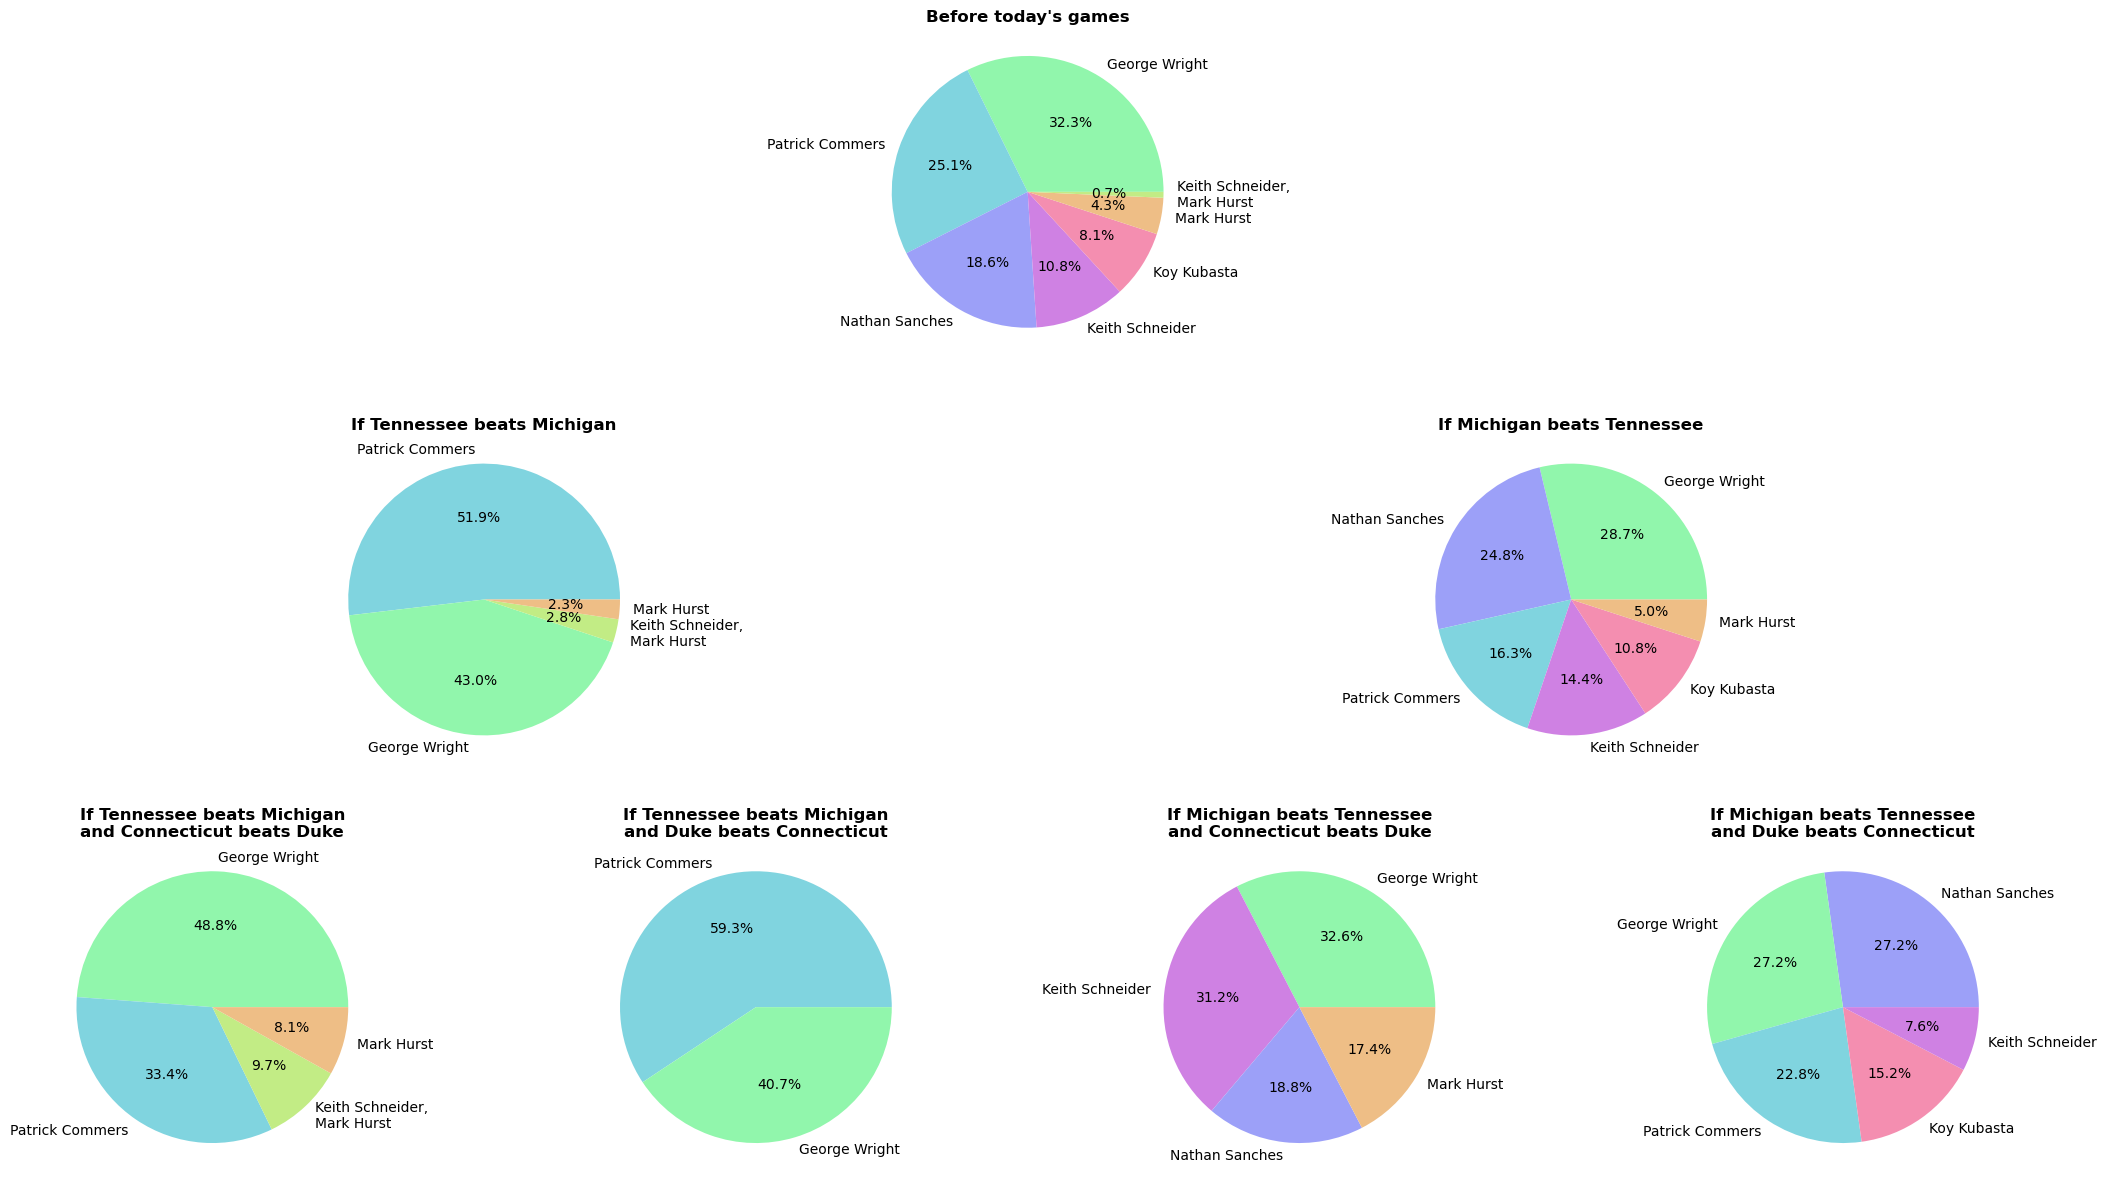

In [45]:
fig, axs = plt.subplots(3, 1, figsize = [10, 15])


ax = axs[0]
df = dfs[0]
labels = df.index


colors = [color_dict[label] for label in labels]
labels = [_.replace(', ', ',\n') for _ in labels]

pie0 = ax.pie(df['Probability'], 
              labels=labels,
              autopct='%1.1f%%',
              normalize=True,
              colors=colors)

title="Before today's games"
ax.text(0, 1.25, title, ha='center', fontsize='large', fontweight='bold')

ax = axs[1]
df = dfs[1]
labels = df.index

colors = [color_dict[label] for label in labels]
labels = [_.replace(', ', ',\n') for _ in labels]

pie1 = ax.pie(df['Probability'], 
              labels=labels,
              autopct='%1.1f%%',
              normalize=True,
              colors=colors)
shift_pie(pie1, -4)

title = f"If {game1[0]} beats {game1[1]}"
ax.text(-4, 1.25, title, ha='center', fontsize='large', fontweight='bold')

df = dfs[2]
labels = df.index

colors = [color_dict[label] for label in labels]
labels = [_.replace(', ', ',\n') for _ in labels]

pie2 = ax.pie(df['Probability'], 
              labels=labels,
              autopct='%1.1f%%',
              normalize=True,
              colors=colors)
shift_pie(pie2, 4)

title = f"If {game1[1]} beats {game1[0]}"
ax.text(4, 1.25, title, ha='center', fontsize='large', fontweight='bold')

ax = axs[2]

df = dfs[3]
labels = df.index

colors = [color_dict[label] for label in labels]
labels = [_.replace(', ', ',\n') for _ in labels]

pie3 = ax.pie(df['Probability'], 
              labels=labels,
              autopct='%1.1f%%',
              normalize=True,
              colors=colors)
shift_pie(pie3, -6)

title = f"If {game1[0]} beats {game1[1]}\nand {game2[0]} beats {game2[1]}"
ax.text(-6, 1.25, title, ha='center', fontsize='large', fontweight='bold')

df = dfs[4]
labels = df.index

colors = [color_dict[label] for label in labels]

pie4 = ax.pie(df['Probability'], 
              labels=labels,
              autopct='%1.1f%%',
              normalize=True,
              colors=colors)
shift_pie(pie4, -2)

title = f"If {game1[0]} beats {game1[1]}\nand {game2[1]} beats {game2[0]}"
ax.text(-2, 1.25, title, ha='center', fontsize='large', fontweight='bold')

df = dfs[5]
labels = df.index

colors = [color_dict[label] for label in labels]
labels = [_.replace(', ', ',\n') for _ in labels]

pie5 = ax.pie(df['Probability'], 
              labels=labels,
              autopct='%1.1f%%',
              normalize=True,
              colors=colors)
shift_pie(pie5, 2)

title = f"If {game1[1]} beats {game1[0]}\nand {game2[0]} beats {game2[1]}"
ax.text(2, 1.25, title, ha='center', fontsize='large', fontweight='bold')

df = dfs[6]
labels = df.index

colors = [color_dict[label] for label in labels]
labels = [_.replace(', ', ',\n') for _ in labels]

pie6 = ax.pie(df['Probability'], 
              labels=labels,
              autopct='%1.1f%%',
              normalize=True,
              colors=colors)
shift_pie(pie6, 6)

title = f"If {game1[1]} beats {game1[0]}\nand {game2[1]} beats {game2[0]}"
ax.text(6, 1.25, title, ha='center', fontsize='large', fontweight='bold')
plt.savefig('plots/two_game_tree_for.png', dpi=300, bbox_inches='tight')